In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jayjoshi37/smartphone-usage-and-addiction-prediction/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv



*This notebook solves the binary classification problem - Addicted or Not Addicted - using Logistic Regression and Artificial Neural Network models. It also includes Exploratory Data Analysis (EDA) with data visualization followed by model training and testing for accuracy*

In [2]:
# Reading the data
data = pd.read_csv(r"/kaggle/input/datasets/jayjoshi37/smartphone-usage-and-addiction-prediction/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
data.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [3]:
data.shape

(7500, 16)

# Exploratory Data Analysis & Data Visualization

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

*'addicted_label' is the target variable with values 0 and 1 classifying a user to be addicted or not addicted to smartphones*

In [5]:
data['addicted_label'].unique()

array([0, 1])

In [6]:
data['addiction_level'].unique()

array([nan, 'Mild', 'Moderate', 'Severe'], dtype=object)

In [7]:
data['stress_level'].unique()

array(['Medium', 'High', 'Low'], dtype=object)

addicted_label
1    5308
0    2192
Name: count, dtype: int64

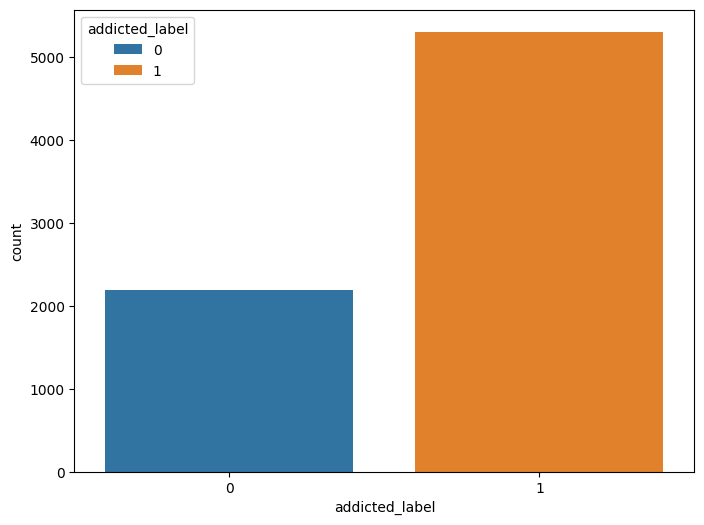

In [8]:
#import the required libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.countplot(
    data=data,
    x='addicted_label',
    hue='addicted_label',
)
data['addicted_label'].value_counts()

addiction_level
Moderate    2874
Severe      2434
Mild        1373
Name: count, dtype: int64

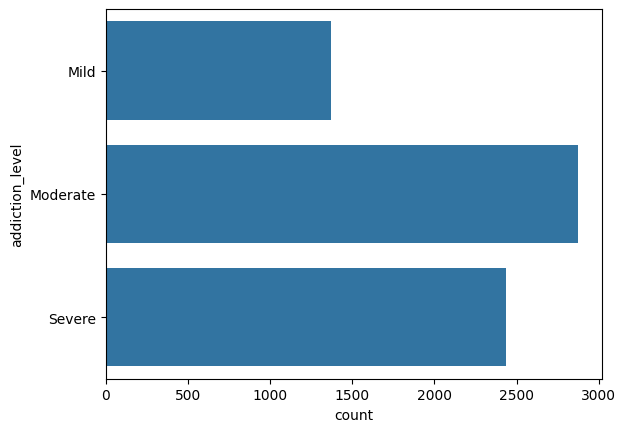

In [9]:
sns.countplot(data['addiction_level'],label="Count")
data['addiction_level'].value_counts()

stress_level
High      2560
Low       2503
Medium    2437
Name: count, dtype: int64

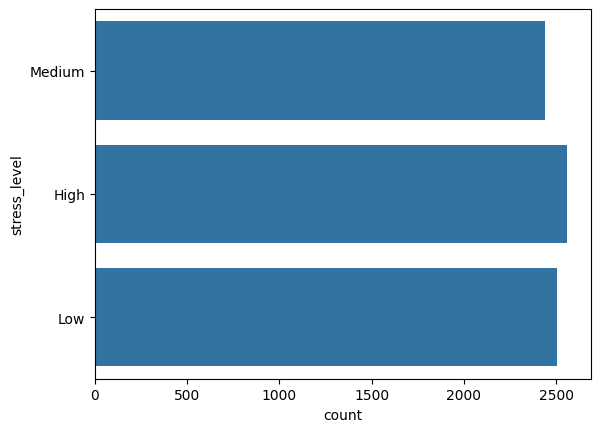

In [10]:
sns.countplot(data['stress_level'],label="Count")
data['stress_level'].value_counts()

gender
Male      2553
Other     2486
Female    2461
Name: count, dtype: int64

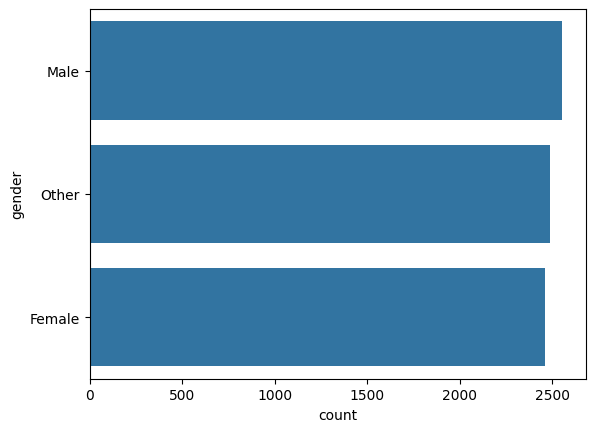

In [11]:
sns.countplot(data['gender'],label="Count")
data['gender'].value_counts()

<Axes: xlabel='stress_level', ylabel='addicted_label'>

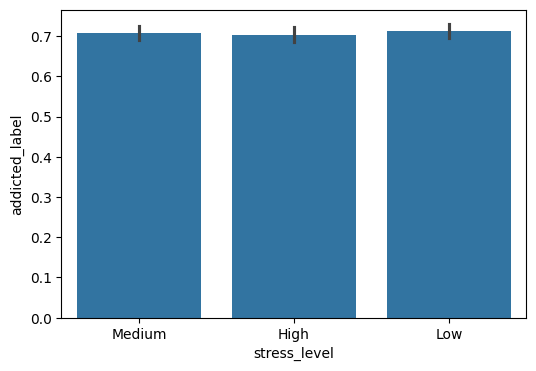

In [12]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=data,
    x='stress_level',
    y='addicted_label'
)

In [13]:
#Average stats
print("Average daily screen time ", data['daily_screen_time_hours'].mean())
print("Average social_media_hours ", data['social_media_hours'].mean())
print("Average weekend_screen_time", data['weekend_screen_time'].mean())
print("Average gaming_hours", data['gaming_hours'].mean())
print("Average sleep_hours", data['sleep_hours'].mean())

Average daily screen time  7.499911999999999
Average social_media_hours  3.273484
Average weekend_screen_time 9.243826666666669
Average gaming_hours 2.0141826666666667
Average sleep_hours 6.737561333333333


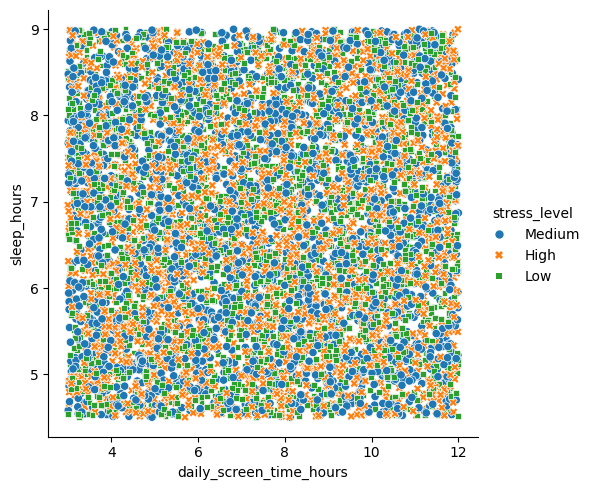

In [14]:
sns.relplot(data = data, x="daily_screen_time_hours",y="sleep_hours",hue="stress_level",style="stress_level")

<Axes: xlabel='daily_screen_time_hours', ylabel='Density'>

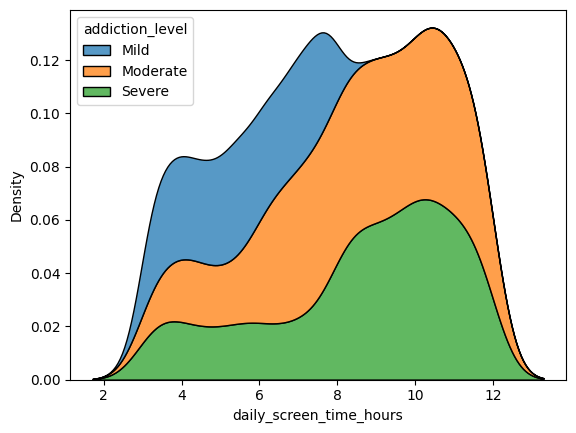

In [15]:
sns.kdeplot(data=data, x="daily_screen_time_hours", hue="addiction_level", multiple="stack")

<Axes: xlabel='social_media_hours', ylabel='Density'>

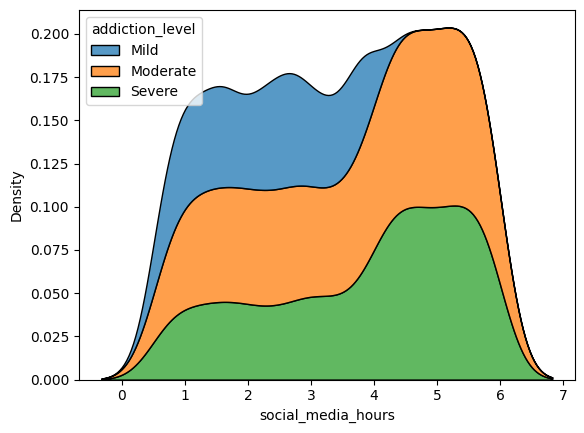

In [16]:
sns.kdeplot(data=data, x="social_media_hours", hue="addiction_level", multiple="stack")

<Axes: xlabel='weekend_screen_time', ylabel='Density'>

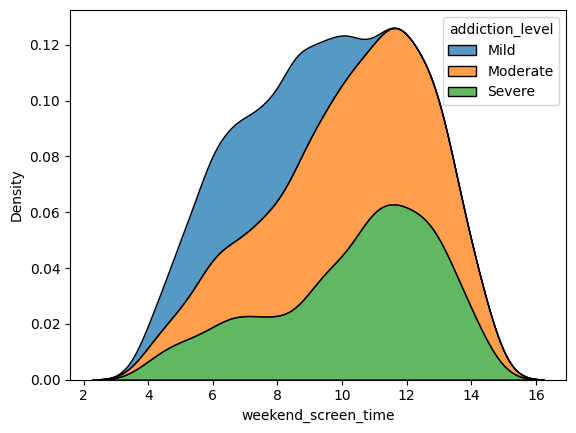

In [17]:
sns.kdeplot(data=data, x="weekend_screen_time", hue="addiction_level", multiple="stack")

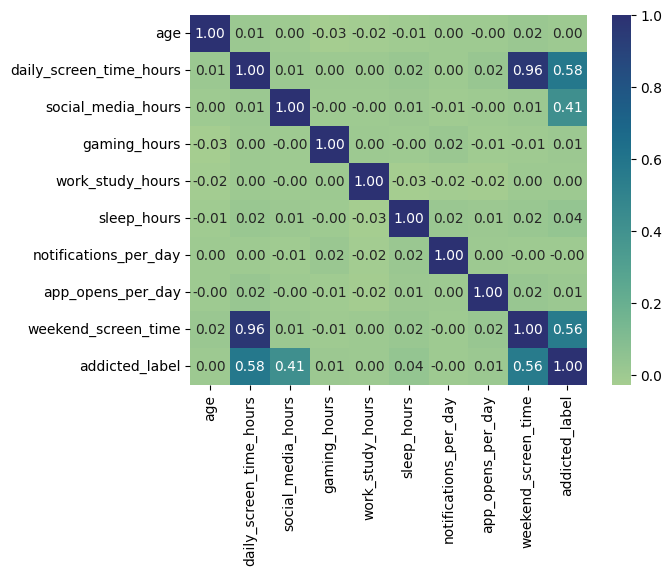

In [18]:
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='crest', fmt=".2f")
plt.show()

*As per the heatmap, features 'daily_screen_time_hours', 'social_media_hours', 'weekend_screen_time' show high correlation with the target variable 'addicted_label'.The remaining features donot impact 'addicted_label' as much. The models are trained with these three features only.*

In [19]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.3)

train_X_data = train[['daily_screen_time_hours', 'social_media_hours', 'weekend_screen_time']].copy()
test_X_data = test[['daily_screen_time_hours', 'social_media_hours', 'weekend_screen_time']].copy()
train_Y_data = train[['addicted_label']].copy()
test_Y_data = test[['addicted_label']].copy()
print(train_X_data.shape, train_Y_data.shape)
print(test_X_data.shape, test_Y_data.shape)

(5250, 3) (5250, 1)
(2250, 3) (2250, 1)


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(train_X_data, train_Y_data.values.ravel())

rf_pred = rf_model.predict(test_X_data)

print("Random Forest Accuracy:", accuracy_score(test_Y_data, rf_pred))

print(classification_report(test_Y_data, rf_pred))

Random Forest Accuracy: 0.9395555555555556
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       683
           1       0.96      0.95      0.96      1567

    accuracy                           0.94      2250
   macro avg       0.93      0.93      0.93      2250
weighted avg       0.94      0.94      0.94      2250



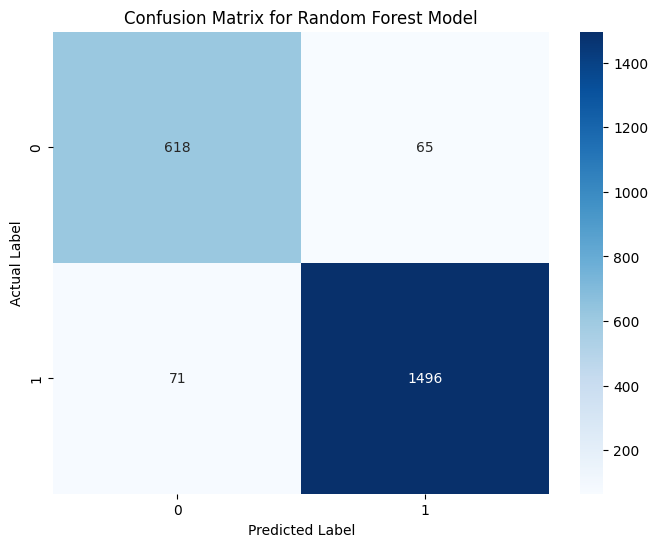

In [21]:
cm = confusion_matrix(test_Y_data, rf_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.title("Confusion Matrix for Random Forest Model")

plt.show()

                   Feature  Importance
1       social_media_hours    0.416606
0  daily_screen_time_hours    0.347576
2      weekend_screen_time    0.235818


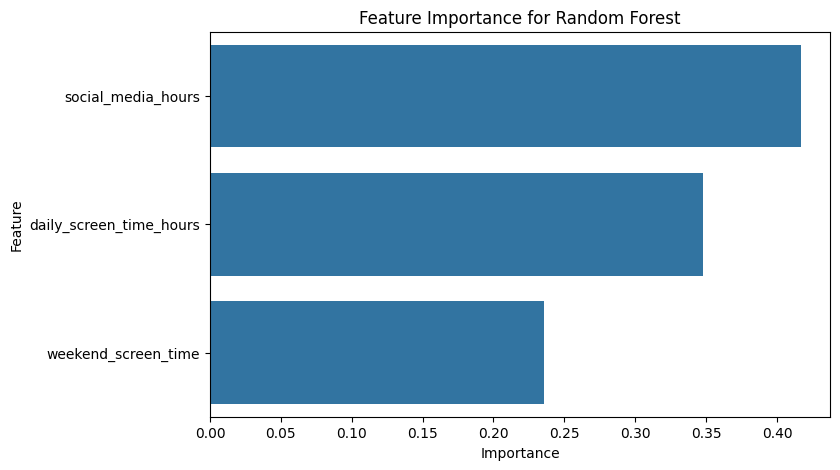

In [22]:
feature_importance = pd.DataFrame({
    "Feature": train_X_data.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance for Random Forest")

plt.show()

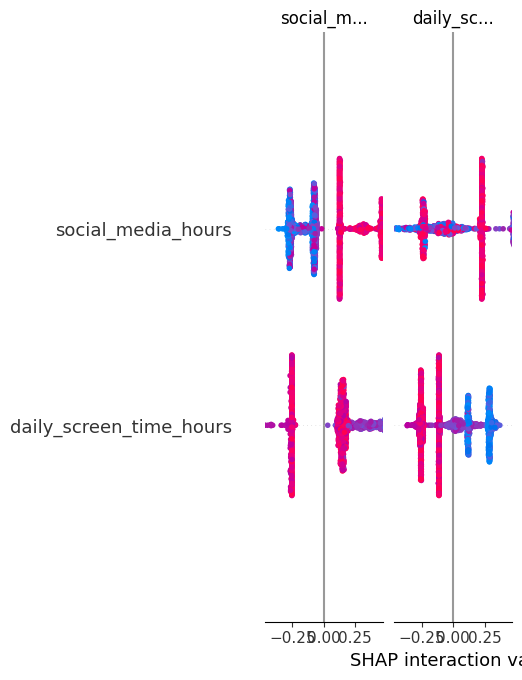

In [23]:
import shap

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(test_X_data)

shap.summary_plot(shap_values, test_X_data)

In [24]:
#Normalizing the data
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler()

# Fit and transform the data
normalized_training_data = scaler.fit_transform(train_X_data)
normalized_testing_data = scaler.fit_transform(test_X_data) 

# Logistic Regression model

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

logistic_regression_model = LogisticRegression()
logistic_regression_model.fit(train_X_data, train_Y_data)

LogisticRegression()

In [26]:
logistic_regression_model.score(test_X_data, test_Y_data) # test on test data 

0.8942222222222223

In [27]:
y_pred = logistic_regression_model.predict(test_X_data)

# Get the classification report as a string
report_string = classification_report(test_Y_data, y_pred, target_names=['addicted','not addicted'])
print(report_string)

              precision    recall  f1-score   support

    addicted       0.84      0.80      0.82       683
not addicted       0.92      0.93      0.92      1567

    accuracy                           0.89      2250
   macro avg       0.88      0.87      0.87      2250
weighted avg       0.89      0.89      0.89      2250



# Artificial Neural Network

In [28]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers

EPOCHS = 300
HIDDEN_UNITS = 128
BATCH_SIZE = 512
VERBOSE = 1
HIDDEN_LAYER_ACTIVATION = 'relu'
OUTPUT_LAYER_ACTIVATION = 'sigmoid'

model = Sequential()
model.add(Dense(HIDDEN_UNITS, input_dim=3, activation=HIDDEN_LAYER_ACTIVATION))
model.add(Dense(HIDDEN_UNITS, activation=HIDDEN_LAYER_ACTIVATION))
model.add(Dense(1, activation=OUTPUT_LAYER_ACTIVATION))

model.compile(loss='binary_crossentropy',optimizer='SGD', metrics=['acc'])

2026-05-15 12:27:35.065485: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778848055.325524      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778848055.394711      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778848055.962101      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778848055.962163      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778848055.962167      16 computation_placer.cc:177] computation placer alr

In [29]:
# Training the model.
model.fit(train_X_data, train_Y_data,
               epochs=EPOCHS,
               verbose=VERBOSE, batch_size= BATCH_SIZE)

Epoch 1/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.5943 - loss: 0.7088  
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.7187 - loss: 0.5030 
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.7096 - loss: 0.5065 
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7174 - loss: 0.4940 
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7066 - loss: 0.4995 
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7174 - loss: 0.4843 
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7194 - loss: 0.4799 
Epoch 8/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7140 - loss: 0.4824 
Epoch 9/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7017 - loss: 0.4884 
Epoch 10/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7121 - loss: 0.4771 
Epoch 11/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7116 - loss: 0.4725 
Epoch 12/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7130 - loss: 0.4701 
Epoch 13/300
11/11 ━━━━━

In [30]:
#evaluate the model
test_loss, test_acc = model.evaluate(test_X_data, test_Y_data)
print('Test accuracy:', test_acc)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9081 - loss: 0.2466
Test accuracy: 0.9048888683319092


In [31]:
y_pred = (model.predict(test_X_data) > 0.5).astype("int32")

# Get the classification report as a string
report_string = classification_report(test_Y_data, y_pred, target_names=['addicted','not addicted'])
print(report_string)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

    addicted       0.76      1.00      0.86       683
not addicted       1.00      0.86      0.93      1567

    accuracy                           0.90      2250
   macro avg       0.88      0.93      0.90      2250
weighted avg       0.93      0.90      0.91      2250



# Conclusion

*ANN model performs better than Logistic Regression. As such, Logistic Regression is a special case of Artificial Neural Network with 1 neuron, no hidden layers and Sigmoid activation.Logistic regression is a single-layer linear model using sigmoid, while neural networks extend this by adding hidden layers and non-linear activations to learn complex patterns*